# Data & Things

## Lecture : IoT and Data

# Simulate sensor data & apply PCA

In this exercise, you will do the following:
1. Simulate sensor data
2. Apply PCA to simulated data
3. Simulate a new point
4. Find out which region the new point belongs to

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Step 1 Simulate synthetic predictive maintenance dataset
np.random.seed(42)
time_steps = 10000

sensors = {}
for i in range(1, 21):
    sensors[f'Sensor{i}'] = np.linspace(50, 100, time_steps) + np.random.normal(0, 20, time_steps)

# Combine into a DataFrame
data = pd.DataFrame(sensors)

print("Sample Data:")
print(data.head())

Sample Data:
     Sensor1    Sensor2    Sensor3    Sensor4    Sensor5    Sensor6  \
0  59.934283  36.430105  56.965725  10.388561  40.562849  51.964123   
1  47.239714  43.895011  55.671472  28.905288  70.259050  48.722836   
2  62.963772  38.062380  31.279604  38.269433  46.046264  69.045816   
3  80.475599  52.223362  61.606686  53.008380  51.826387  80.671624   
4  45.336935  73.963573  20.218348  70.503249  64.367814  63.756941   

     Sensor7    Sensor8    Sensor9   Sensor10   Sensor11   Sensor12  \
0  51.576755  56.403048  63.280022  69.217891  70.611892  66.017477   
1  61.262950  72.314233  44.082680  42.605706  26.897905  49.021813   
2  56.832040  19.905237  48.678273  38.418383  61.518745  41.079748   
3  24.456718  84.807115  46.507354  68.681245  37.630232  53.375301   
4  46.295596  56.621738  60.301076  -4.610793  43.471946   7.484493   

    Sensor13   Sensor14   Sensor15   Sensor16   Sensor17   Sensor18  \
0  45.626995  72.350652  44.689254  77.397560  78.652455  13.5

In [3]:
# Step 2: Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Display scaled data
print("Scaled Data Sample:")
print(pd.DataFrame(scaled_data, columns=data.columns).head())

Scaled Data Sample:
    Sensor1   Sensor2   Sensor3   Sensor4   Sensor5   Sensor6   Sensor7  \
0 -0.610580 -1.566006 -0.725010 -2.596654 -1.407431 -0.927666 -0.969437   
1 -1.126525 -1.265030 -0.777771 -1.850742 -0.198347 -1.057996 -0.572396   
2 -0.487452 -1.500195 -1.772111 -1.473524 -1.184173 -0.240819 -0.754021   
3  0.224281 -0.929241 -0.535820 -0.879792 -0.948835  0.226649 -2.081098   
4 -1.203859 -0.052701 -2.223025 -0.175043 -0.438209 -0.453482 -1.185914   

    Sensor8   Sensor9  Sensor10  Sensor11  Sensor12  Sensor13  Sensor14  \
0 -0.746813 -0.479506 -0.232249 -0.186682 -0.367113 -1.184181 -0.110562   
1 -0.106939 -1.258090 -1.320570 -1.955170 -1.054209 -0.697301 -0.772550   
2 -2.214587 -1.071707 -1.491814 -0.554553 -1.375289 -0.412171 -0.701019   
3  0.395468 -1.159753 -0.254195 -1.520984 -0.878208 -1.964016 -1.982653   
4 -0.738018 -0.600323 -3.251518 -1.284652 -2.733470 -0.924990 -0.686938   

   Sensor15  Sensor16  Sensor17  Sensor18  Sensor19  Sensor20  
0 -1.220616  0

Do the following tasks:
1. Apply PCA with upto 5 components
2. Visualize how much variance of the dataset is defined by each component
3. Visualize the first 2 principal components and color them by timestep
4. Simulate a new position using code below
5. Plot the new point in the original 2D PCA graph

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the diabetes dataset (replace the path if necessary)
df = pd.read_csv("diabetes.csv")  # Assuming your file is named "diabetes.csv"


In [18]:
# Check for missing values
print("Missing values in the dataset:")
print(df.isnull().sum())  # Show missing values for each column

# If missing values are present, fill them with the mean of each column
df.fillna(df.mean(), inplace=True)

# Ensure no missing values remain
print("\nMissing values after filling:")
print(df.isnull().sum())  # Should show zeros for all columns


Missing values in the dataset:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing values after filling:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [19]:
# Select relevant features for PCA (ensure they are numeric)
features = df[['Glucose', 'BloodPressure', 'Insulin']]  # Modify the features as necessary
labels = df['Outcome']  # Target variable (Outcome)

# Standardize the features (PCA requires standardized data)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)  # Standardize the data


In [20]:
# Check the shape of the scaled_features data
print(f"Shape of scaled_features: {scaled_features.shape}")

# Check the data types to ensure all columns are numeric
print(f"Data types of the features:\n{df.dtypes}")


Shape of scaled_features: (768, 3)
Data types of the features:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [21]:
# Apply PCA with 3 components since the dataset only has 3 features
pca = PCA(n_components=3)

# Apply PCA transformation to the scaled features
try:
    pca_result = pca.fit_transform(scaled_features)

    # Print the explained variance ratio for each component
    print("Explained Variance Ratio by each component:")
    print(pca.explained_variance_ratio_)

except ValueError as e:
    print(f"Error applying PCA: {e}")


Explained Variance Ratio by each component:
[0.46801342 0.31139748 0.2205891 ]


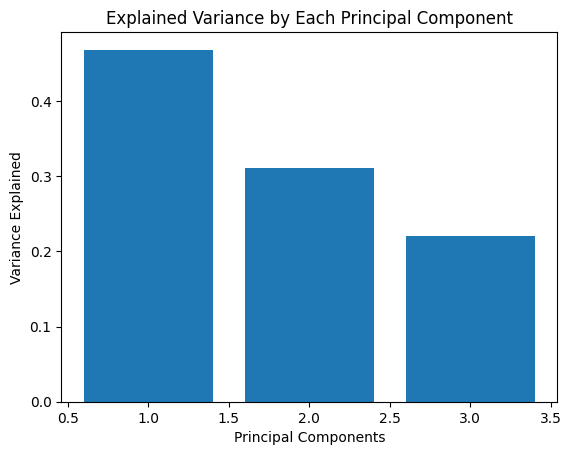

In [22]:
# Plot the explained variance ratio for each principal component
plt.bar(range(1, 4), pca.explained_variance_ratio_)
plt.xlabel('Principal Components')
plt.ylabel('Variance Explained')
plt.title('Explained Variance by Each Principal Component')
plt.show()


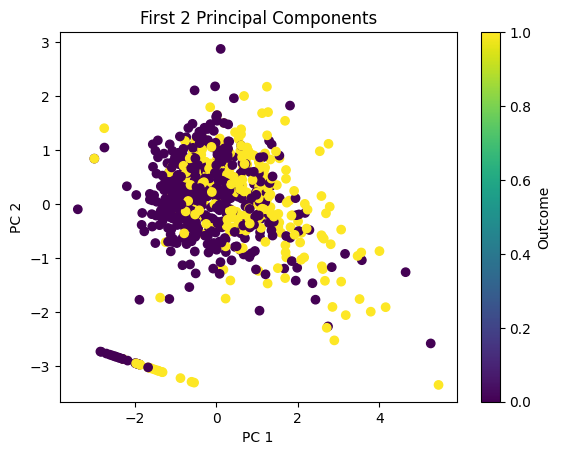

In [24]:
# Scatter plot of the first two principal components, colored by 'Outcome' (labels)
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='viridis')
plt.xlabel('PC 1')  # Label for the first principal component
plt.ylabel('PC 2')  # Label for the second principal component
plt.title('First 2 Principal Components')
plt.colorbar(label='Outcome')  # Colorbar to show Outcome classes
plt.show()


In [27]:
# Example new observation (e.g., Glucose = 75, Insulin = 20)
new_observation = np.array([75, 20])  # New observation array

# Standardize the new observation using the same scaler
# Reshape to 2D to avoid the warning
# Convert to DataFrame with appropriate column names to match the scaler's fit
new_observation_df = pd.DataFrame(new_observation.reshape(1, -1), columns=['Glucose', 'BloodPressure', 'Insulin'])

# Now apply the scaler
scaled_new_obs = scaler.transform(new_observation_df)  # Use DataFrame here to avoid feature name warning

# Transform the new observation into PCA space
new_pca_position = pca.transform(scaled_new_obs)

# Print the new observation's PCA position
print("New observation PCA position:", new_pca_position)

# Scatter plot of the first two principal components with the new observation
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='viridis')  # Color by Outcome
plt.scatter(new_pca_position[0, 0], new_pca_position[0, 1], color='red', marker='x')  # Add new observation as red 'X'
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('New Point in PCA Space')
plt.colorbar(label='Outcome')  # Colorbar to show Outcome values
plt.show()


ValueError: Shape of passed values is (1, 2), indices imply (1, 3)